# Projeto de Machine Learning – Eficiência Energética de Edificações

## Contexto

O consumo energético em edificações é um fator essencial para eficiência operacional e sustentabilidade. Neste trabalho, busca-se analisar e prever o consumo energético com base em características estruturais.

Inspirado em conceitos de Controle Estatístico de Processo (CEP), este estudo também analisa a variabilidade dos dados e o comportamento do processo.

## Formulação do Problema

Trata-se de um problema de aprendizado supervisionado, no qual deseja-se aprender uma função f(X) → Y, onde:

- X: características das edificações
- Y: consumo energético (Heating Load)

O objetivo é construir um modelo capaz de generalizar para novos dados.

Dataset: https://archive.ics.uci.edu/ml/machine-learning-databases/00242/ENB2012_data.xlsx

## Hipóteses

- Características estruturais influenciam o consumo energético
- Existe variabilidade significativa no processo

In [ ]:
# IMPORTAÇÃO E DADOS

import pandas as pd
import numpy as np

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00242/ENB2012_data.xlsx"
df = pd.read_excel(url)

df.head()

,X1,X2,X3,X4,X5,X6,X7,X8,Y1,Y2
0,0.98,514.5,294.0,110.25,7.0,2,0.0,0,15.55,21.33
1,0.98,514.5,294.0,110.25,7.0,3,0.0,0,15.55,21.33
2,0.98,514.5,294.0,110.25,7.0,4,0.0,0,15.55,21.33
3,0.98,514.5,294.0,110.25,7.0,5,0.0,0,15.55,21.33
4,0.90,563.5,318.5,122.50,7.0,2,0.0,0,20.84,28.28


In [ ]:
# EXPLORAÇÃO DOS DADOS

df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   X1      768 non-null    float64
 1   X2      768 non-null    float64
 2   X3      768 non-null    float64
 3   X4      768 non-null    float64
 4   X5      768 non-null    float64
 5   X6      768 non-null    int64  
 6   X7      768 non-null    float64
 7   X8      768 non-null    int64  
 8   Y1      768 non-null    float64
 9   Y2      768 non-null    float64
dtypes: float64(8), int64(2)
memory usage: 60.1 KB


,0
X1,0
X2,0
X3,0
X4,0
X5,0
X6,0
X7,0
X8,0
Y1,0
Y2,0


O dataset contém variáveis relacionadas às características físicas das edificações e duas variáveis alvo:

- Y1: Heating Load
- Y2: Cooling Load

In [ ]:
# PRÉ-PROCESSAMENTO

df = df.dropna()

X = df.drop(['Y1','Y2'], axis=1)
y = df['Y1']

In [ ]:
# TREINO E TESTE

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

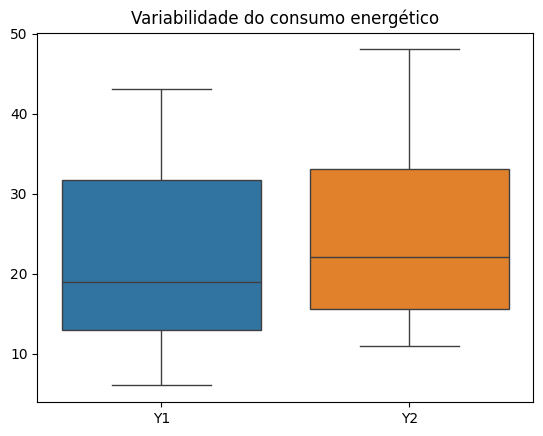

In [ ]:
# ANÁLISE EXPLORATÓRIA

import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(data=df[['Y1','Y2']])
plt.title("Variabilidade do consumo energético")
plt.show()

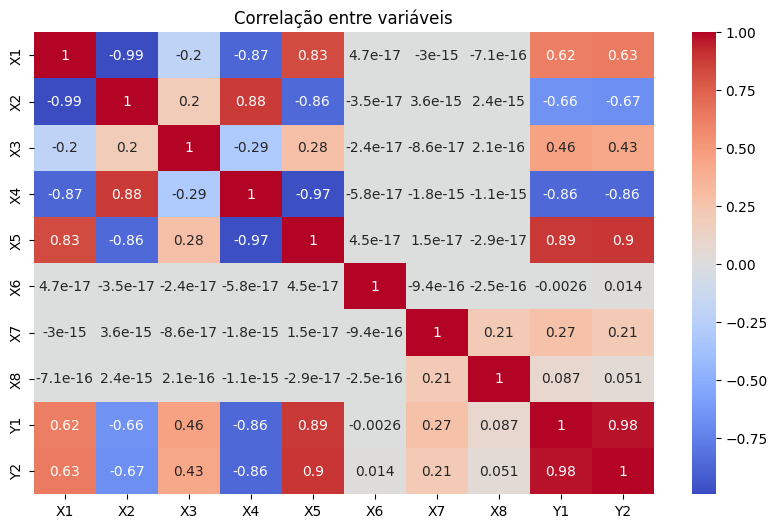

In [ ]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlação entre variáveis")
plt.show()

Observa-se variabilidade significativa nos dados, indicando diferenças no comportamento energético das edificações, o que é compatível com sistemas reais.

In [ ]:
# MODELAGEM

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor

model1 = LinearRegression()
model2 = RandomForestRegressor()
model3 = DecisionTreeRegressor()
model4 = KNeighborsRegressor()

model1.fit(X_train, y_train)
model2.fit(X_train, y_train)
model3.fit(X_train, y_train)
model4.fit(X_train, y_train)

KNeighborsRegressor()

In [ ]:
# AVALIAÇÃO

from sklearn.metrics import mean_squared_error, r2_score

models = {
    "Linear Regression": model1,
    "Random Forest": model2,
    "Decision Tree": model3,
    "KNN": model4
}

for name, model in models.items():
    pred = model.predict(X_test)
    print(f"\n{name}")
    print("MSE:", mean_squared_error(y_test, pred))
    print("R2:", r2_score(y_test, pred))


Linear Regression
MSE: 9.15320764594167
R2: 0.9121846294352439

Random Forest
MSE: 0.23660048051947852
R2: 0.9977300680071615

Decision Tree
MSE: 0.385239324675325
R2: 0.9963040351141297

KNN
MSE: 4.85465490909091
R2: 0.9534247078951772


In [ ]:
# VALIDAÇÃO CRUZADA

from sklearn.model_selection import cross_val_score

scores = cross_val_score(model2, X, y, cv=5)

print("Scores:", scores)
print("Média:", scores.mean())
print("Desvio:", scores.std())

Scores: [0.84169017 0.99589631 0.9968852  0.99659889 0.99411375]
Média: 0.9650368636577349
Desvio: 0.0616808806081106


A validação cruzada fornece uma estimativa mais robusta da capacidade de generalização do modelo.

In [ ]:
# OTIMIZAÇÃO

from sklearn.model_selection import GridSearchCV

params = {'n_estimators':[50,100,150]}

grid = GridSearchCV(RandomForestRegressor(), params)
grid.fit(X_train, y_train)

print("Melhores parâmetros:", grid.best_params_)

Melhores parâmetros: {'n_estimators': 150}


In [ ]:
# IMPORTÂNCIA DAS VARIÁVEIS

import pandas as pd

importances = model2.feature_importances_
features = X.columns

df_imp = pd.DataFrame({'Feature':features,'Importance':importances})
df_imp.sort_values(by='Importance', ascending=False)

,Feature,Importance
0,X1,0.423161
1,X2,0.162501
3,X4,0.159395
4,X5,0.118474
6,X7,0.078823
2,X3,0.043664
7,X8,0.013222
5,X6,0.000759


**ANÁLISE (OVERFITTING / UNDERFITTING)**

Modelos mais complexos, como Random Forest, apresentam maior capacidade de capturar padrões, porém podem sofrer overfitting.

Modelos simples podem apresentar underfitting, não capturando a complexidade do problema.

O equilíbrio entre viés e variância é essencial para um bom desempenho.

**CONCLUSÃO**

O modelo Random Forest apresentou melhor desempenho entre os avaliados, indicando maior capacidade preditiva.

A validação cruzada confirmou a robustez do modelo, demonstrando boa capacidade de generalização.

Observa-se que o consumo energético depende significativamente das características estruturais das edificações.

A análise baseada em conceitos de Controle Estatístico de Processo mostrou variabilidade relevante, indicando a importância do monitoramento contínuo.